In [119]:
from sklearn.datasets import make_classification
import numpy as np
x, y = make_classification(n_samples=500, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=1)

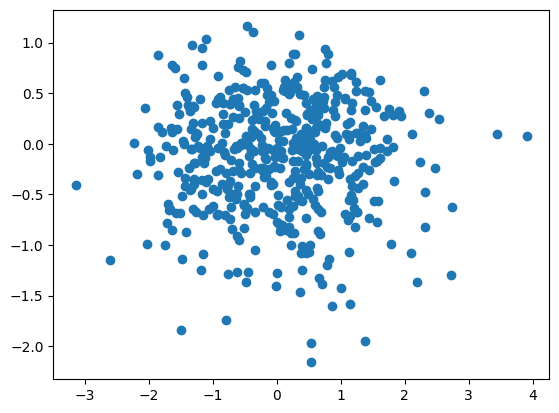

In [120]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1])

In [121]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [122]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [123]:
from sklearn.svm import SVC
svc = SVC(kernel = "linear")
svc.fit(x_train,y_train)

SVC(kernel='linear')

In [124]:
from sklearn.metrics import accuracy_score
print("for logistic ",accuracy_score(y_test,lr.predict(x_test)))
print("for svm ",accuracy_score(y_test,svc.predict(x_test)))

for logistic  0.55
for svm  0.58


In [125]:
rbf = SVC(kernel = "rbf")
rbf.fit(x_train,y_train)
accuracy_score(y_test,rbf.predict(x_test))

0.64

In [129]:
poly = SVC(kernel = "poly")
poly.fit(x_train,y_train)
accuracy_score(y_test,poly.predict(x_test))

0.69

In [130]:
sig = SVC(kernel = "sigmoid")
sig.fit(x_train,y_train)
accuracy_score(y_test,sig.predict(x_test))

0.5

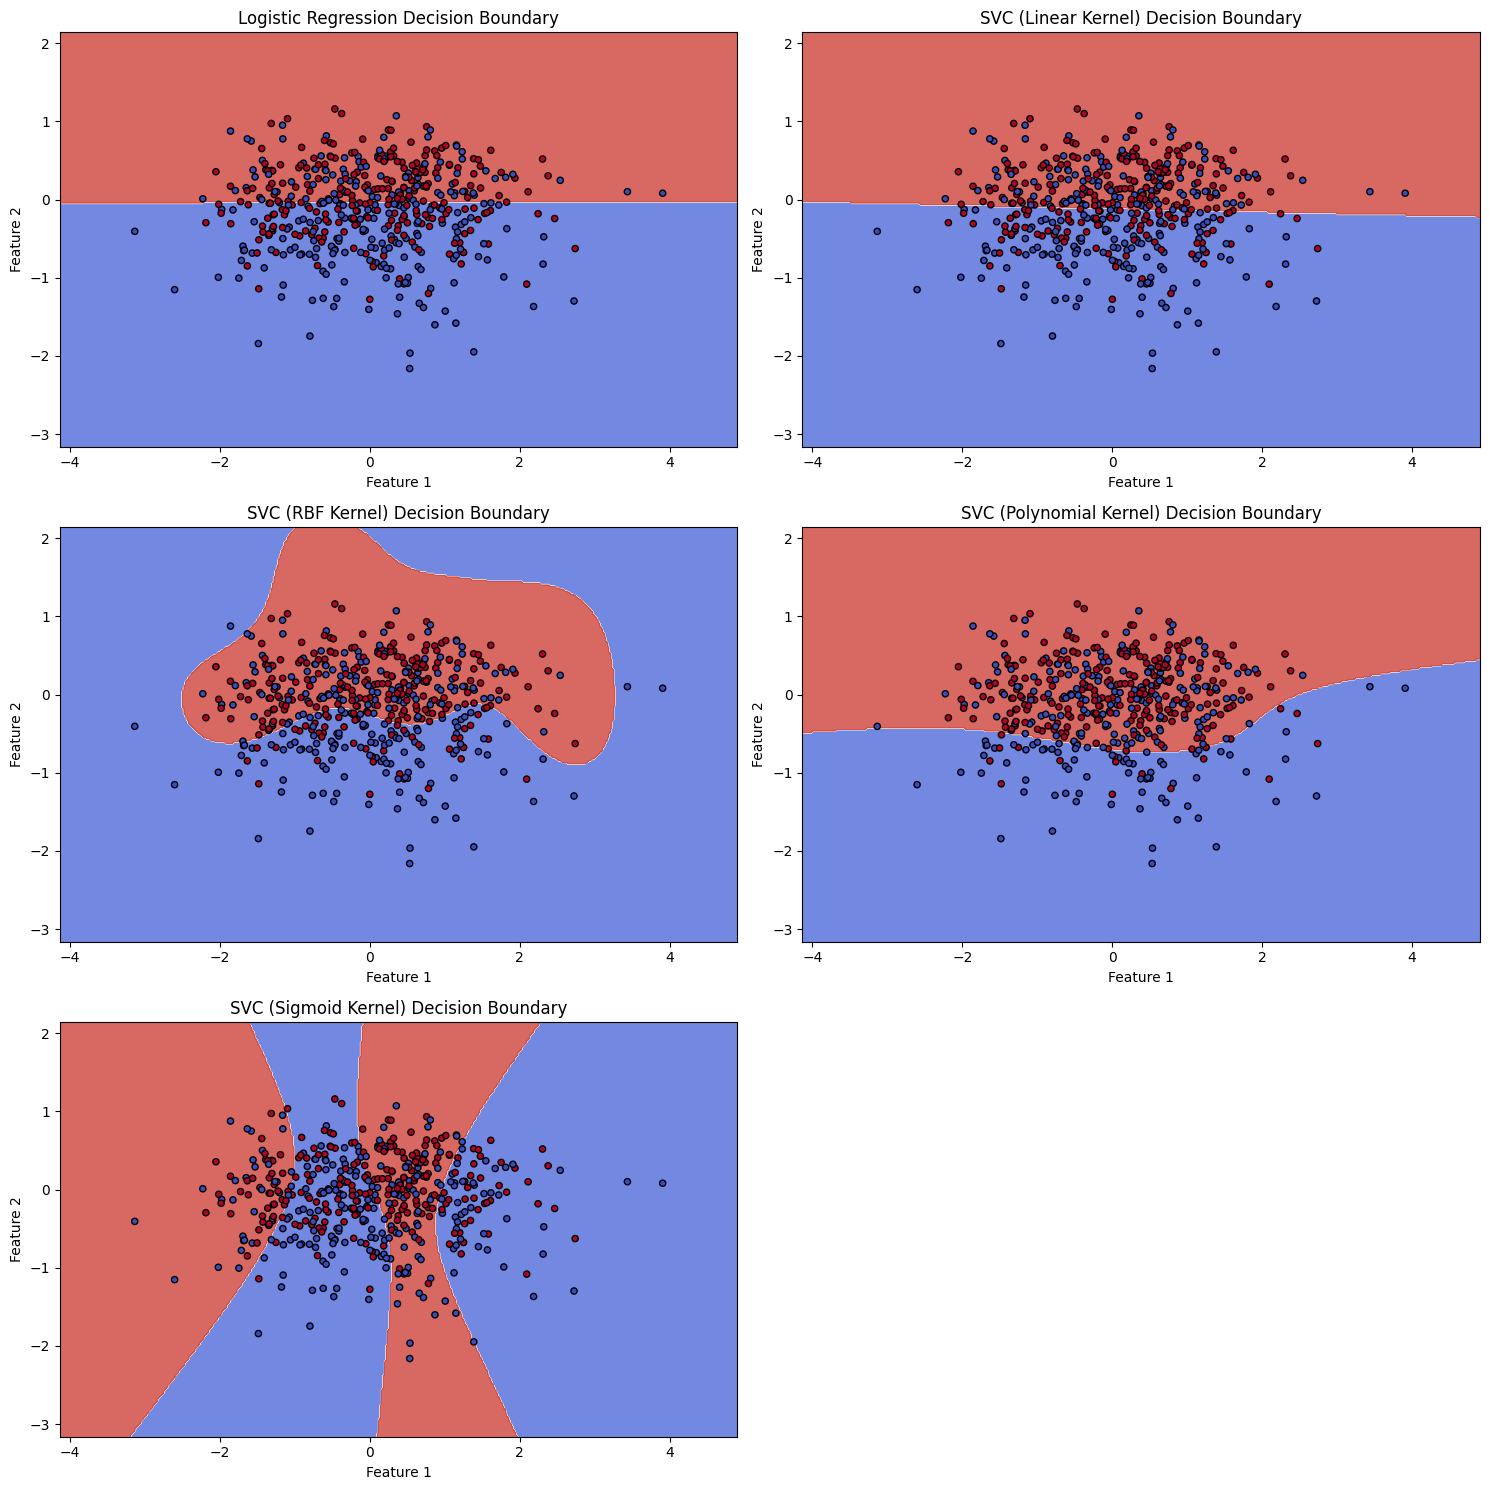

In [136]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

plt.figure(figsize=(15, 15))

def plot_decision_boundary(ax, model, title):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    ax.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')


# Logistic Regression
ax1 = plt.subplot(3, 2, 1)
plot_decision_boundary(ax1, lr, 'Logistic Regression Decision Boundary')

# SVC with Linear Kernel
ax2 = plt.subplot(3, 2, 2)
plot_decision_boundary(ax2, svc, 'SVC (Linear Kernel) Decision Boundary')

# SVC with RBF Kernel
ax3 = plt.subplot(3, 2, 3)
plot_decision_boundary(ax3, rbf, 'SVC (RBF Kernel) Decision Boundary')

# SVC with Polynomial Kernel
ax4 = plt.subplot(3, 2, 4)
plot_decision_boundary(ax4, poly, 'SVC (Polynomial Kernel) Decision Boundary')

# SVC with Sigmoid Kernel
ax5 = plt.subplot(3, 2, 5)
plot_decision_boundary(ax5, sig, 'SVC (Sigmoid Kernel) Decision Boundary')

plt.tight_layout()
plt.show()

/tmp/ipykernel_616/480155922.py:18: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, Z_lr, colors='blue', levels=[0.5], linestyles='--', linewidths=2, label='Logistic Regression')
/tmp/ipykernel_616/480155922.py:23: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, Z_svc, colors='green', levels=[0.5], linestyles='-', linewidths=2, label='SVC (Linear Kernel)')


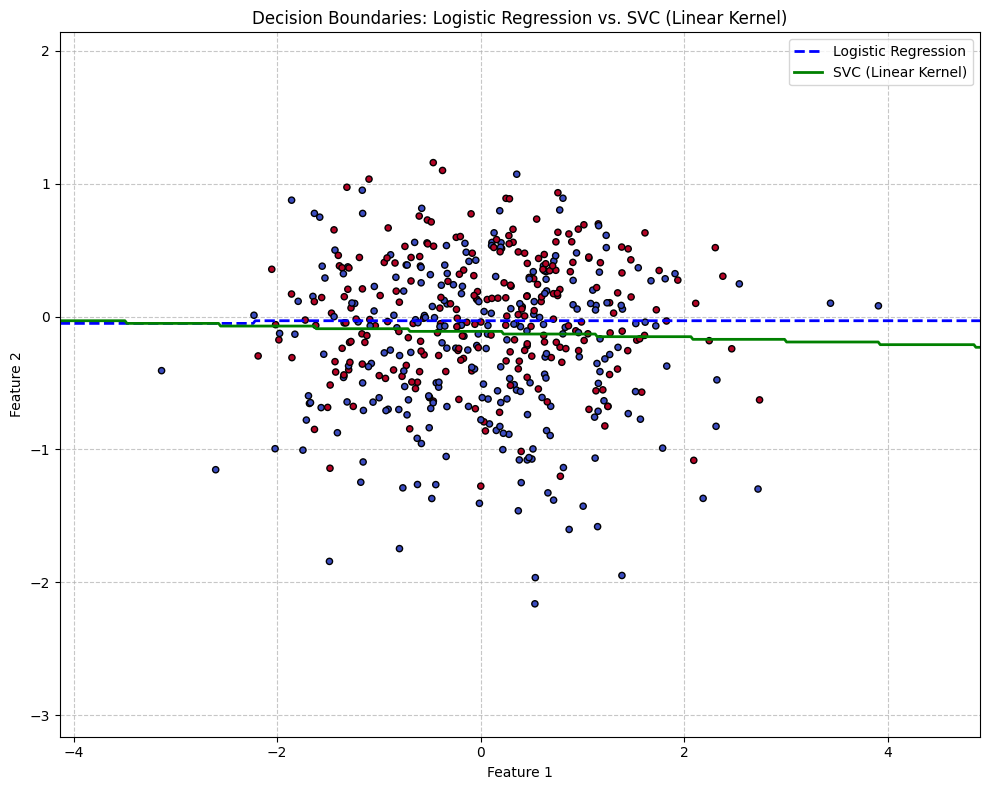

In [134]:
import matplotlib.pyplot as plt
import numpy as np

x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

plt.figure(figsize=(10, 8))
ax = plt.gca()

# Plot the data points
ax.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k', zorder=2)

# Plot Logistic Regression decision boundary
Z_lr = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lr = Z_lr.reshape(xx.shape)
ax.contour(xx, yy, Z_lr, colors='blue', levels=[0.5], linestyles='--', linewidths=2, label='Logistic Regression')

# Plot SVC (Linear Kernel) decision boundary
Z_svc = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svc = Z_svc.reshape(xx.shape)
ax.contour(xx, yy, Z_svc, colors='green', levels=[0.5], linestyles='-', linewidths=2, label='SVC (Linear Kernel)')

# Manually create legend entries for contour lines
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, linestyle='--', label='Logistic Regression'),
    Line2D([0], [0], color='green', lw=2, linestyle='-', label='SVC (Linear Kernel)')
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_title('Decision Boundaries: Logistic Regression vs. SVC (Linear Kernel)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()